# Fund Workstation

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT LS','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [ ]:
test = load_saved_json(folder_path=r"input/test")
print(type(test))
json_fund = init_funds(test)
print(json_fund)

#### Load Data via .csv

In [2]:
csv_fund = input_monthly_returns(r"RETURN DATA.csv")



#### GPT Input Factsheet

In [3]:
gpt_fund = process_pdfs_in_folder(folder_path=r"input\portfolio",save=True)

Processing: input\portfolio\3WCF 202508 investor newsletter.pdf
{
  "fund_name": "3W CHINA",
  "fund_des": "3W Greater China Focus Fund is a long/short equity fund focusing on Greater China markets with a net long exposure of 23.25%. The fund emphasizes TMT and financial sectors, managed by 3W Fund Management Limited. It has a strong track record since inception in 2012, with a 2% management fee and 20% performance fee. Rated 4 for consistent performance and regional expertise.",
  "performance": {
    "table": [
      ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "July", "Aug", "Sep", "Oct", "Nov", "Dec", "YTD"],
      ["0.0208", "0.0154", "-0.0012", "-0.012", "-0.0009", "0.0102", "0.0314", "0.028", "", "", "", "", "0.0944"],
      ["-0.0106", "0.0036", "0.0139", "0.022", "0.0121", "0.0054", "0.0007", "0.0023", "0.0338", "0.0012", "-0.0018", "0.0267", "0.114"],
      ["0.0403", "-0.015", "0.0213", "-0.0137", "-0.0122", "0.0072", "0.0044", "-0.0019", "0.0041", "0.0067", "-0.0023", "0.0077

ValueError: could not convert string to float: 'E20'

#### Process Input

In [ ]:
# Use csv to update json
overwrited_new = merge_funds(csv_fund, gpt_fund)
joined = json_fund | gpt_fund

#### Save the Changes

In [ ]:
save_changes_in_fund(merged)

### Compare Multiple Funds

In [ ]:
df = compare_funds(merged)
print(df["Name"].to_list())
df

In [ ]:
# Combine all conditions in a single filter
mask = (df["Sharpe Ratio"] > 1) & (df["Annualized Return"] > 0.1) 

# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", 
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

# Then, select only the columns you want
df['Worth a Look'] = mask
filtered = df[["Name", "Location","Strategy", "Worth a Look","AUM", "Sharpe Ratio", "Annualized Return", "Max Drawdown","Description"]]
filtered

In [ ]:
filtered.to_csv("output/funds_comparison.csv", index=False)

#### Compare Performance Table

In [ ]:
funds['RDGFF'].export_monthly_table(benchmark = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)
funds['RDGFF'].export_monthly_table(benchmark = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

### Plot Cumulative Retrun Graphs

In [6]:

funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'EUREKAHEDGE','MSCI CHINA'])
start_month = "2007-12"
end_month = "2024-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=True,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


### Correlation Heat Map

In [ ]:
# Correlation heatmap

funds_to_be_plot = funds
start_month = "2019-12"
end_month = "2020-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

In [ ]:
print(type(funds['RDGFF']))

None
No contact info


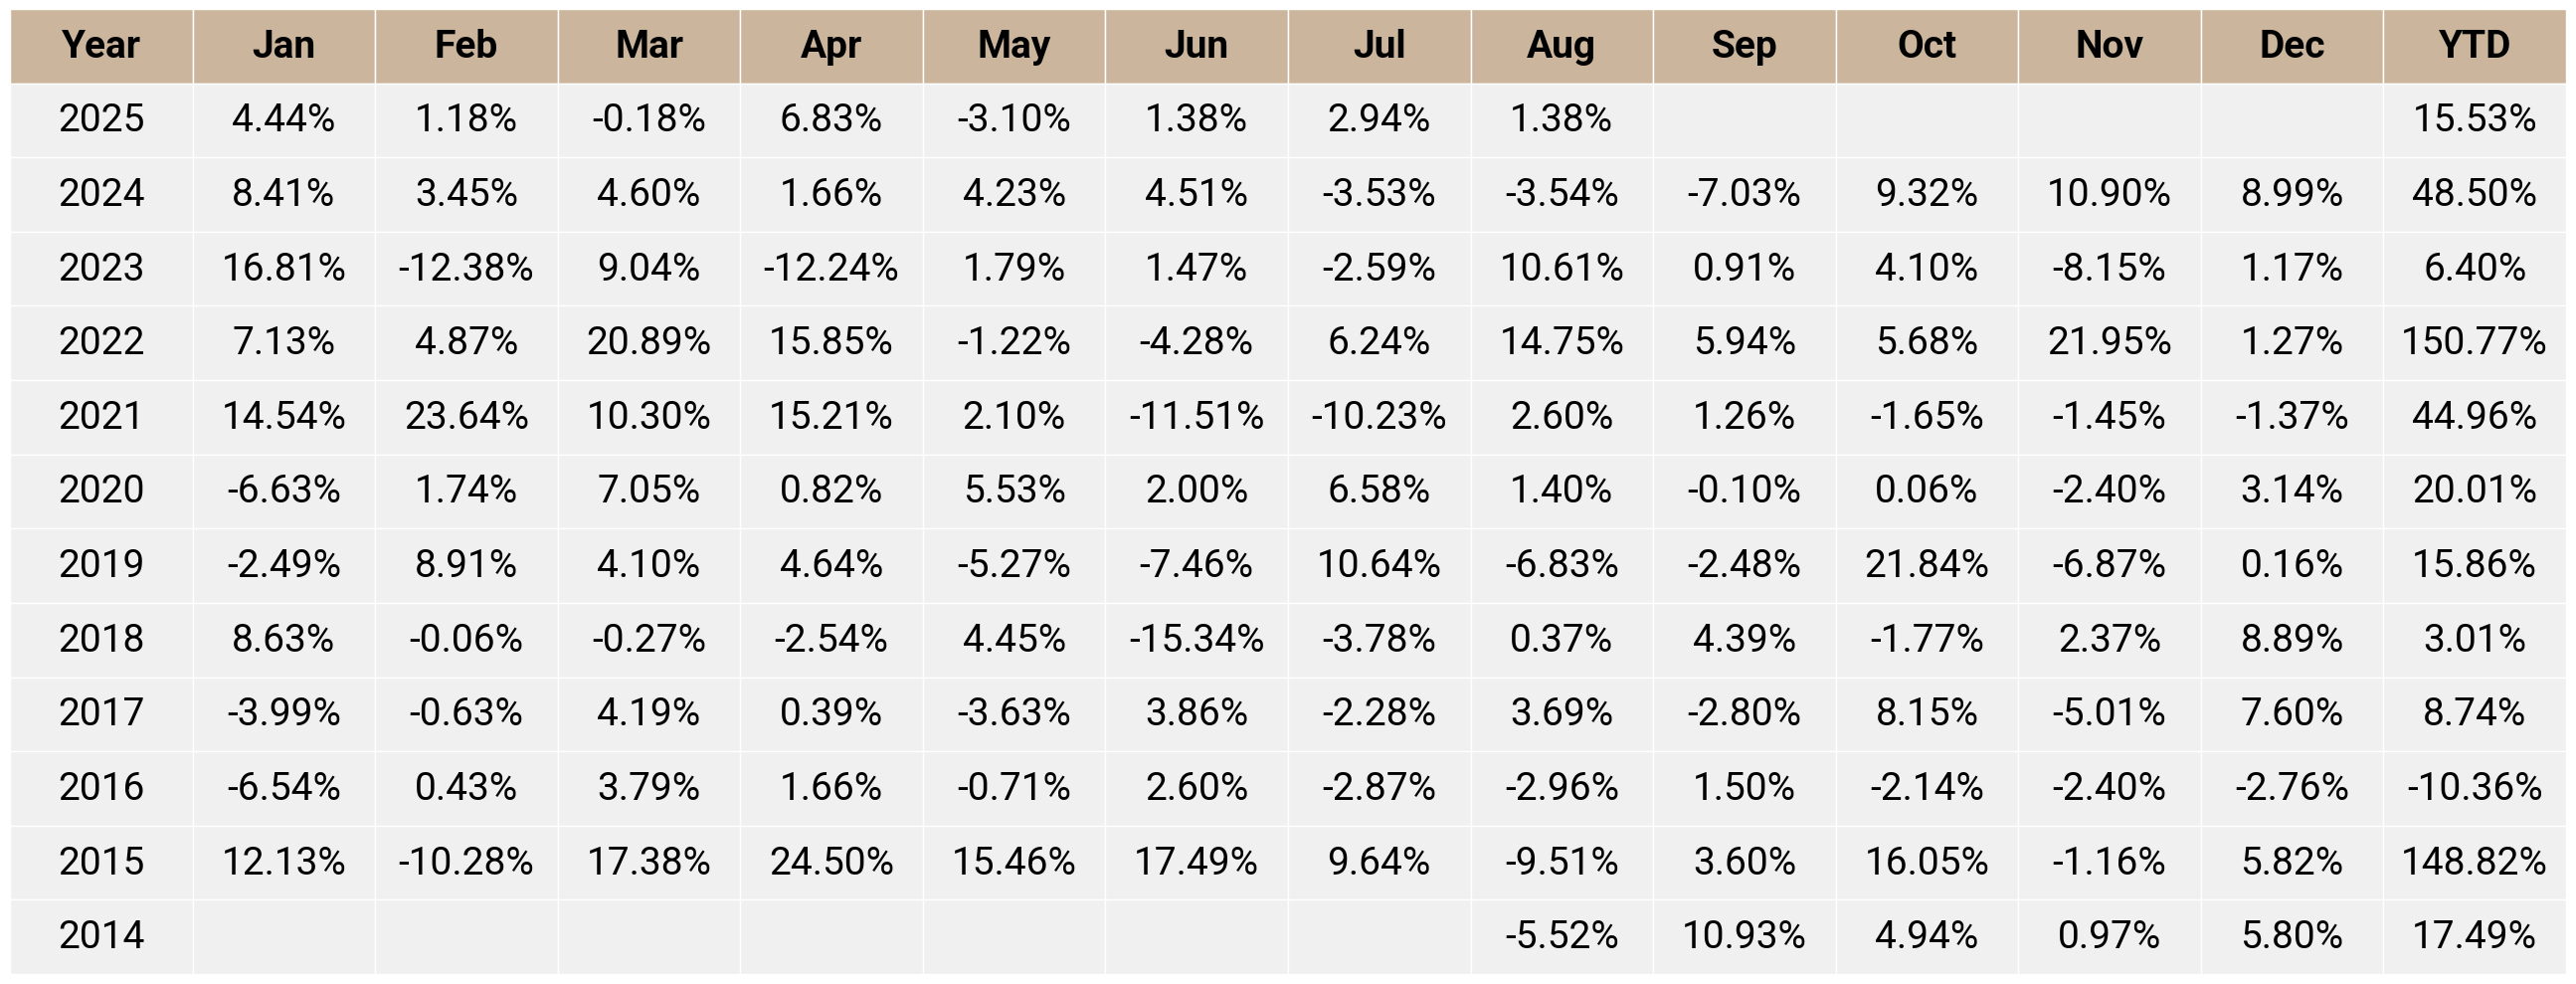

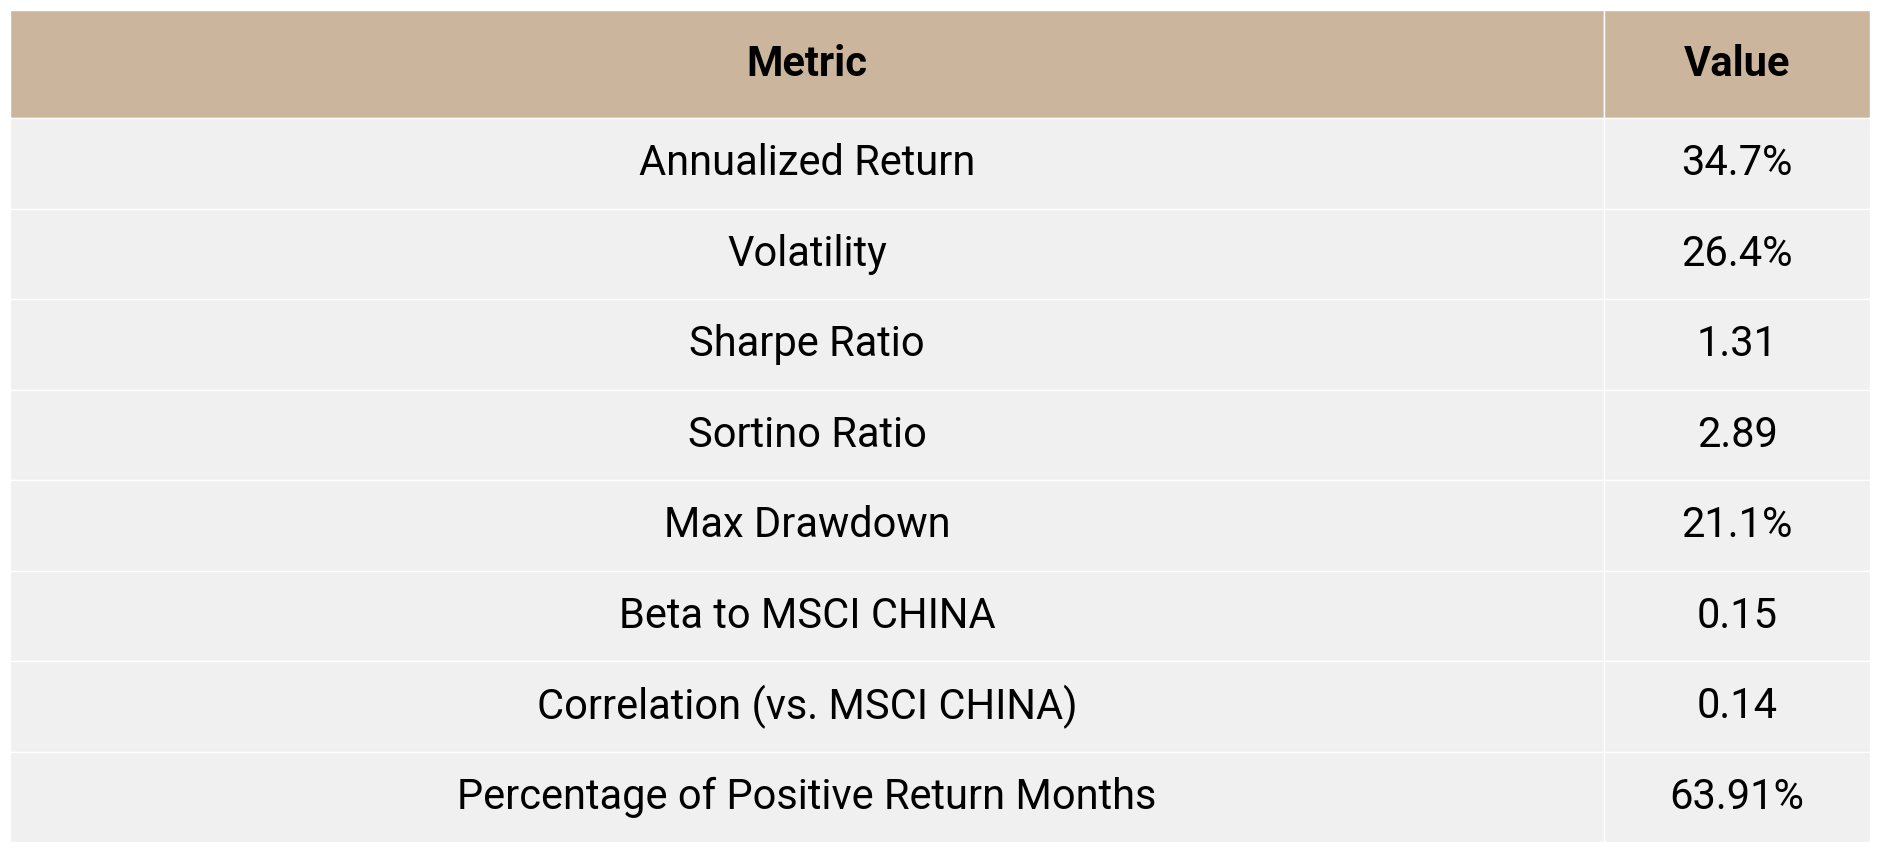

c:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1463: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [3]:
funds['HAO'].summary_of_a_fund(benchmark_fund =funds['MSCI CHINA'],language="en")

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )